In [2]:
import pandas as pd

In [3]:
swiss_prot_plants_sm = pd.read_csv("../data/swiss_prot_ec_plants.csv")

In [4]:
from ec_number_prediction.data_processing_pipeline.multi_label_binarizer import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
final_dataset = mlb.divide_labels_by_EC_level("../data/swiss_prot_ec_plants.csv")
final_dataset = mlb.get_final_labels(final_dataset)

EC1 is not null


In [5]:
final_dataset

,accession,name,sequence,EC,lineage,species,taxonomy_id,EC1,EC2,EC3,...,7.2.2.12,7.2.2.21,7.2.2.8,7.2.2.9,7.3.2.3,7.4.2.4,7.6.2.1,7.6.2.2,7.6.2.4,7.6.2.5
0,Q7XQ85,1A12_ORYSJ,MAYQGIDLLSTKAAGDDHGENSSYFDGWKAYDTNPFDLRHNRGGVI...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,P18485,1A12_SOLLC,MGFEIAKTNSILSKLATNEEHGENSPYFDGWKAYDSDPFHPLKNPN...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A0A0P0WIY3,1A13_ORYSJ,MVGRMLSSPEPTLSTMAMSAAHGEDSPYFAGWRAYDEDPYDPITNP...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Q42881,1A13_SOLLC,MKLLSEKATCNSHGQDSSYFLGWQEYEKNPYDEIQNPKGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Q43309,1A14_ARATH,MVQLSRKATCNSHGQVSSYFLGWEEYEKNPYDVTKNPQGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15514,Q9FLM3,ZDH23_ARATH,MYVVTPPQRSGFGSDCDLRVYQTWKGSNIFCLQGRFIFGPDVRSLG...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,2,2.3,2.3.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15515,Q8VYS8,ZDH24_ARATH,MAGRVFEAWKGSNKFLFGGRLIFGPDAWSIPFTFLLIITPVCFFSV...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,2,2.3,2.3.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15516,Q9C533,ZDHC1_ARATH,MRKHGWQLPYHPLQVVAVAVFLALGFAFYVFFAPFVGKKIHQYIAM...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,2,2.3,2.3.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15517,Q3EC11,ZDHC2_ARATH,MDSSEIEVVPLDSNSHQSPTESPTITDVFSASAYGDLHQLKHFVEH...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,2,2.3,2.3.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
import re

def get_ec_levels(labels):
    level_1 = []
    level_2 = []
    level_3 = []
    level_4 = []
    for i, label in enumerate(labels):
        if re.match(r"^\d+.\d+.\d+.n*\d+$", label):
            level_4.append(i)
        elif re.match(r"^\d+.\d+.\d+$", label):
            level_3.append(i)
        elif re.match(r"^\d+.\d+$", label):
            level_2.append(i)
        elif re.match(r"^\d+$", label):
            level_1.append(i)
    return level_1, level_2, level_3, level_4

level_1, level_2, level_3, level_4 = get_ec_levels(final_dataset.columns[11:])

In [7]:
y_true_ = final_dataset.iloc[:, 11:]
y_true_ = y_true_.to_numpy()

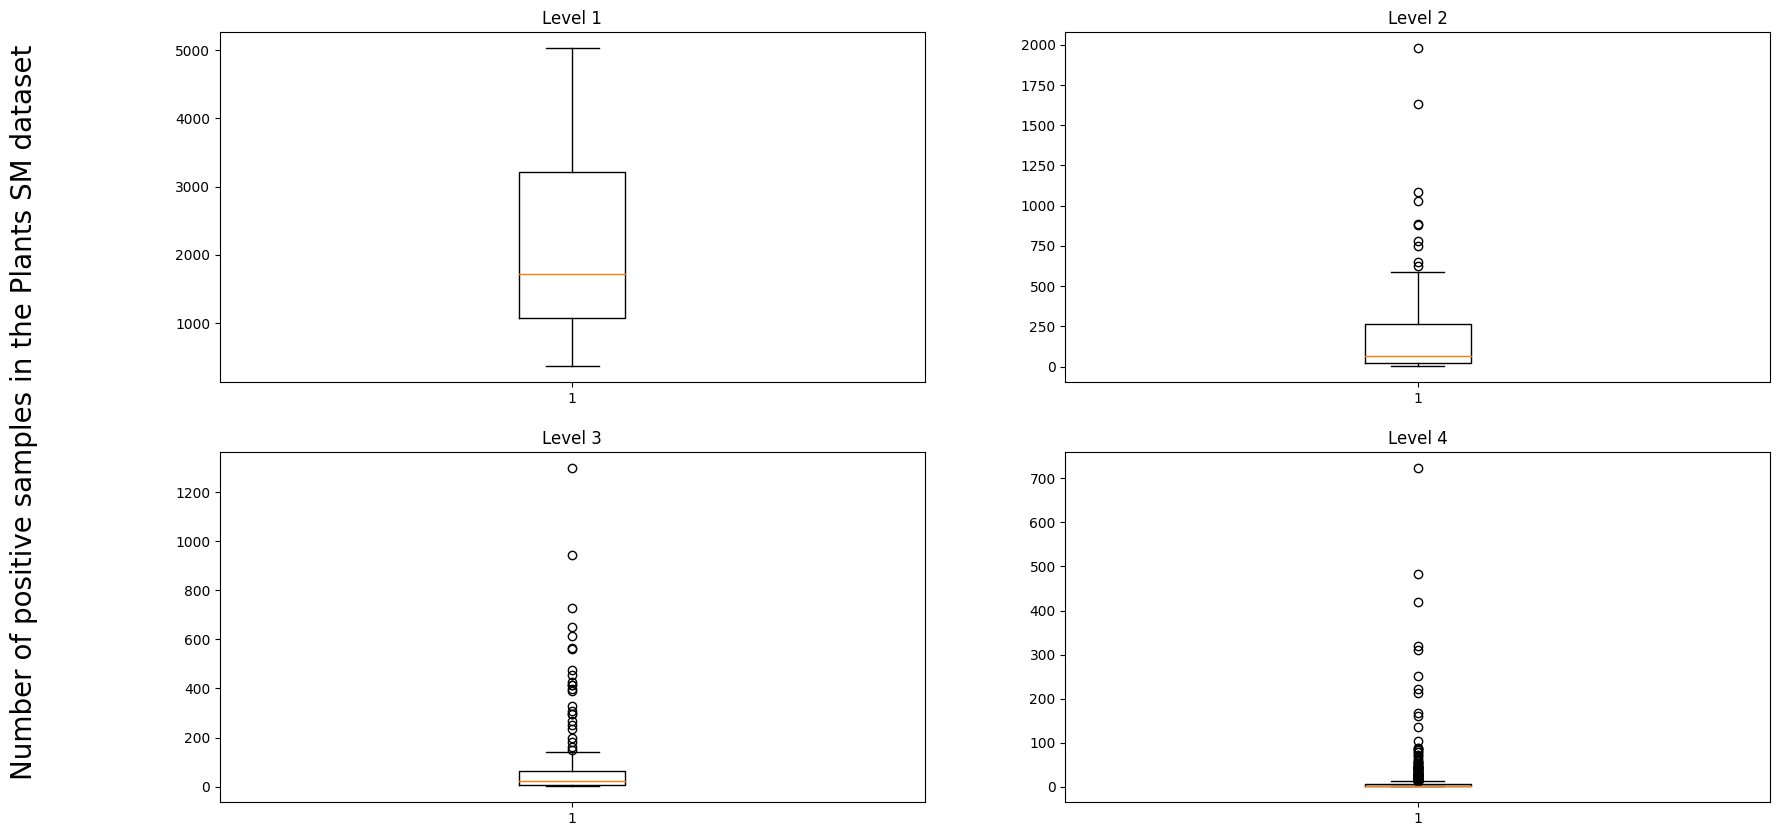

In [8]:
# get distribution of labels for level 4
import numpy as np

# remove all 0 values and create boxplot for level 4
y_true_level_4 = y_true_[:, level_4]
y_true_level_4 = y_true_level_4[y_true_level_4.sum(axis=1) != 0]
distribution_level4 = y_true_level_4.sum(axis=0)

y_true_level_3 = y_true_[:, level_3]
y_true_level_3 = y_true_level_3[y_true_level_3.sum(axis=1) != 0]
distribution_level3 = y_true_level_3.sum(axis=0)

y_true_level_2 = y_true_[:, level_2]
y_true_level_2 = y_true_level_2[y_true_level_2.sum(axis=1) != 0]
distribution_level2 = y_true_level_2.sum(axis=0)

y_true_level_1 = y_true_[:, level_1]
y_true_level_1 = y_true_level_1[y_true_level_1.sum(axis=1) != 0]
distribution_level1 = y_true_level_1.sum(axis=0)

# make 4 plots instead of only one
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 10))
plt.subplot(2, 2, 1)
plt.boxplot(distribution_level1)
fig.supylabel('Number of positive samples in the Plants SM dataset', fontsize=20)
# plt.ylabel('Number of positive samples in the evidence-level dataset')
plt.title('Level 1')
plt.subplot(2, 2, 2)
plt.boxplot(distribution_level2)
plt.title('Level 2')
plt.subplot(2, 2, 3)
plt.boxplot(distribution_level3)
plt.title('Level 3')
plt.subplot(2, 2, 4)
plt.boxplot(distribution_level4)
plt.title('Level 4')
plt.show()


In [9]:
import pandas as pd

pd.DataFrame(distribution_level2).describe()

,0
count,64.000000
mean,245.171875
std,399.425363
min,1.000000
25%,19.750000
50%,67.000000
75%,262.750000
max,1979.000000


In [10]:
pd.DataFrame(distribution_level3).describe()

,0
count,181.000000
mean,84.928177
std,174.231010
min,1.000000
25%,6.000000
50%,23.000000
75%,62.000000
max,1298.000000


In [11]:
pd.DataFrame(distribution_level4).describe()

,0
count,1721.000000
mean,7.301569
std,29.198782
min,1.000000
25%,1.000000
50%,2.000000
75%,6.000000
max,723.000000


In [12]:
# drop from dataset all labels that have less than 5 samples
final_dataset_ = final_dataset.iloc[:, 11:]
final_dataset_ = final_dataset_.loc[:, final_dataset_.sum(axis=0) >= 6]
final_dataset_

,1,2,3,4,5,6,7,1.1,1.10,1.11,...,7.1.1.6,7.1.1.8,7.1.1.9,7.1.2.1,7.1.2.2,7.2.2.10,7.2.2.12,7.2.2.21,7.6.2.1,7.6.2.2
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15514,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15515,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15516,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15517,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
final_dataset = pd.concat([final_dataset.iloc[:, :11], final_dataset_], axis=1)
final_dataset

,accession,name,sequence,EC,lineage,species,taxonomy_id,EC1,EC2,EC3,...,7.1.1.6,7.1.1.8,7.1.1.9,7.1.2.1,7.1.2.2,7.2.2.10,7.2.2.12,7.2.2.21,7.6.2.1,7.6.2.2
0,Q7XQ85,1A12_ORYSJ,MAYQGIDLLSTKAAGDDHGENSSYFDGWKAYDTNPFDLRHNRGGVI...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,P18485,1A12_SOLLC,MGFEIAKTNSILSKLATNEEHGENSPYFDGWKAYDSDPFHPLKNPN...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,A0A0P0WIY3,1A13_ORYSJ,MVGRMLSSPEPTLSTMAMSAAHGEDSPYFAGWRAYDEDPYDPITNP...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Oryza sativa subsp. japonica,39947,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Q42881,1A13_SOLLC,MKLLSEKATCNSHGQDSSYFLGWQEYEKNPYDEIQNPKGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Solanum lycopersicum,4081,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Q43309,1A14_ARATH,MVQLSRKATCNSHGQVSSYFLGWEEYEKNPYDVTKNPQGIIQMGLA...,4.4.1.14,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,4,4.4,4.4.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15514,Q9FLM3,ZDH23_ARATH,MYVVTPPQRSGFGSDCDLRVYQTWKGSNIFCLQGRFIFGPDVRSLG...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,2,2.3,2.3.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15515,Q8VYS8,ZDH24_ARATH,MAGRVFEAWKGSNKFLFGGRLIFGPDAWSIPFTFLLIITPVCFFSV...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,2,2.3,2.3.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15516,Q9C533,ZDHC1_ARATH,MRKHGWQLPYHPLQVVAVAVFLALGFAFYVFFAPFVGKKIHQYIAM...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,2,2.3,2.3.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15517,Q3EC11,ZDHC2_ARATH,MDSSEIEVVPLDSNSHQSPTESPTITDVFSASAYGDLHQLKHFVEH...,2.3.1.225,Eukaryota;Viridiplantae;Streptophyta;Embryophy...,Arabidopsis thaliana,3702,2,2.3,2.3.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
X = final_dataset.iloc[:, 0:11]
y = final_dataset.iloc[:, 11:]

In [63]:
import os
from skmultilearn.model_selection import IterativeStratification
from ec_number_prediction.data_processing_pipeline.split import StratifiedSplit

stratifier = IterativeStratification(n_splits=5, order=2)

i=0
for fold in stratifier.split(X, y):
    train_indexes, test_indexes = fold
    print(f"Fold {i}")
    X_train = X.iloc[train_indexes]
    y_train = y.iloc[train_indexes, :]

    X_test = X.iloc[test_indexes]
    y_test = y.iloc[test_indexes, :]

    repetitive_train = []
    for id_ in list(X_train.accession):
        if id_ in list(X_test.accession):
            repetitive_train.append(id_)
    
    y_train = y_train[~X_train["accession"].isin(repetitive_train)]
    X_train = X_train[~X_train["accession"].isin(repetitive_train)]

    splitter = StratifiedSplit()
    df_with_stats, table_styled = splitter.generate_stats(y_train, y_test)

    X_train, y_train, x_test, y_test = splitter.correct_split(X_train, y_train, X_test, y_test, df_with_stats, validation = False, compensation=3)

    train_dataset = pd.concat([X_train, y_train], axis=1)
    test_dataset = pd.concat([x_test, y_test], axis=1)

    if not os.path.exists("../data/plants/train_datasets"):
        os.makedirs("../data/plants/train_datasets")
    if not os.path.exists("../data/plants/test_datasets"):
        os.makedirs("../data/plants/test_datasets")
    if not os.path.exists("../data/plants/validation_datasets"):
        os.makedirs("../data/plants/validation_datasets")

    stratifier = IterativeStratification(n_splits=2, order=2, sample_distribution_per_fold=[0.2, 0.8])
    fold = next(stratifier.split(X_train, y_train))
    train_indexes, validation_indexes = fold
    X_train_ = X_train.iloc[train_indexes]
    y_train_ = y_train.iloc[train_indexes, :]

    X_validation = X_train.iloc[validation_indexes]
    y_validation = y_train.iloc[validation_indexes, :]

    y_train = y_train_[~X_train_["accession"].isin(repetitive_train)]
    X_train = X_train_[~X_train_["accession"].isin(repetitive_train)]

    df_with_stats, table_styled = splitter.generate_stats(y_train_, y_validation)
    X_train, y_train, X_validation, y_validation = splitter.correct_split(X_train, y_train, X_validation, y_validation, df_with_stats, validation = False, compensation=3)

    train_dataset = pd.concat([X_train, y_train], axis=1)
    validation_dataset = pd.concat([X_validation, y_validation], axis=1)

    # shuffle datasets
    train_dataset = train_dataset.sample(frac=1)
    test_dataset = test_dataset.sample(frac=1)
    validation_dataset = validation_dataset.sample(frac=1)

    train_dataset.to_csv(f"../data/plants/train_datasets/train_dataset_{i}.csv", index=False)
    test_dataset.to_csv(f"../data/plants/test_datasets/test_dataset_{i}.csv", index=False)
    validation_dataset.to_csv(f"../data/plants/validation_datasets/validation_dataset_{i}.csv", index=False)
    df_with_stats, table_styled = splitter.generate_stats(y_train, y_test, y_validation)
    table_styled.to_html(f"../data/plants/dataset_{i}_stats.html")
    i+=1

Fold 0
[]
[]
Fold 1
[]
[]
Fold 2
[]
[]
Fold 3
[]
[]
Fold 4
[]
[]


In [64]:
from plants_sm.data_structures.dataset.single_input_dataset import SingleInputDataset

train_dataset = SingleInputDataset.from_csv("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/plants/train_datasets/train_dataset_0.csv", 
                representation_field="sequence", instances_ids_field="accession", labels_field=slice(11, -1))

train_dataset.load_features("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/swiss_prot_ec_plants_prot_bert")

test_dataset = SingleInputDataset.from_csv("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/plants/test_datasets/test_dataset_0.csv",
                representation_field="sequence", instances_ids_field="accession", labels_field=slice(11, -1))

test_dataset.load_features("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/swiss_prot_ec_plants_prot_bert")

In [65]:
valid_dataset = SingleInputDataset.from_csv("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/plants/validation_datasets/validation_dataset_0.csv",
                representation_field="sequence", instances_ids_field="accession", labels_field=slice(11, -1))

In [49]:
valid_dataset.identifiers

array(['Q09FR0', 'Q42588', 'Q9SRT9', ..., 'A9SDL4', 'Q651X7', 'P51824'],
      dtype=object)

In [66]:
valid_dataset = pd.read_csv("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/plants/validation_datasets/validation_dataset_0.csv")
train_dataset = pd.read_csv("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/plants/train_datasets/train_dataset_0.csv")

In [67]:
repetitive_ids = []
for id_ in list(train_dataset.accession):
    if id_ in list(valid_dataset.accession):
        repetitive_ids.append(id_)
repetitive_ids

[]

In [59]:
repetitive_ids = []
for id_ in train_dataset.identifiers:
    if id_ in valid_dataset.identifiers:
        repetitive_ids.append(id_)
repetitive_ids

['P27736',
 'F4J300',
 'Q9S7H8',
 'Q6L3D8',
 'Q9ZNQ8',
 'Q8LGF7',
 'A7Y3B4',
 'Q31730',
 'Q8L940',
 'Q9CA28',
 'Q2R0L0',
 'Q9ZPV8',
 'B2LMQ1',
 'P51820',
 'Q9FH05',
 'C5I9X1',
 'Q9FY48',
 'Q9LIP6',
 'A0A068Q721',
 'Q10G56',
 'E7DN63',
 'Q9FEY5',
 'Q9LXA8',
 'P0DKC3',
 'A0A2R6Q8R5',
 'P16024',
 'F4IJ77',
 'P48579',
 'Q9C9Y7',
 'Q42546',
 'O49227',
 'Q9LV48',
 'Q8VY93',
 'Q43092',
 'P85439',
 'O49296',
 'O22133',
 'Q7G768',
 'Q49L06',
 'O24151',
 'Q9SPK4',
 'A0A348AUW1',
 'Q2MY36',
 'P51092',
 'Q43316',
 'A1YJE3',
 'P56755',
 'A0A0R0HPY5',
 'Q43869',
 'Q8W571',
 'Q9LSS7',
 'Q40518',
 'Q5Z9Z0',
 'Q93VH2',
 'A2WX64',
 'O64749',
 'Q8VZ52',
 'Q09G39',
 'A7X657',
 'Q01873',
 'Q39227',
 'Q0JH50',
 'Q9FFN7',
 'Q0WQX9',
 'Q31951',
 'Q940H7',
 'O49485',
 'A2ZEX7',
 'F4J4C8',
 'F4HVG8',
 'Q9LSV8',
 'A6BM50',
 'O81010',
 'P49333',
 'Q3MKY2',
 'Q67UP9',
 'Q9ZR26',
 'P38661',
 'A9U328',
 'Q2QQR2',
 'Q5VMI0',
 'A0A072VDF2',
 'Q0IQJ7',
 'P09672',
 'Q9M9P3',
 'Q38869',
 'Q56WF8',
 'C3VEQ1',
 'Q3V554',
 

In [ ]:
import pandas as pd

train_dataset = pd.read_csv("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/plants/train_datasets/train_dataset_0.csv")
test_dataset = pd.read_csv("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/plants/test_datasets/test_dataset_0.csv")

# check if there are any missing values
train_dataset.isnull().sum()
test_dataset.isnull().sum()

/tmp/ipykernel_2722317/2476234940.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train_dataset = pd.read_csv("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/plants/train_datasets/train_dataset_0.csv")
/tmp/ipykernel_2722317/2476234940.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  test_dataset = pd.read_csv("/home/jcapela/ec_numbers_prediction/plants_pipeline/data/plants/test_datasets/test_dataset_0.csv")


accession    0
name         0
sequence     0
EC           0
lineage      0
            ..
7.2.2.10     0
7.2.2.12     0
7.2.2.21     0
7.6.2.1      0
7.6.2.2      0
Length: 654, dtype: int64